In [5]:
# %matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.image as img
import numpy as np
import os
import warnings

from copy import copy
from obspy.core import UTCDateTime
from pysep import Pysep
from pysep.recsec import plotw_rs
from obspy import read, read_events, read_inventory
from pysep.utils.cap_sac import append_sac_headers, format_sac_header_w_taup_traveltimes, write_cap_weights_files
# script settings

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = 9, 6

In [6]:
def fetch_and_plot(event, duration, download, plotting, bandpass):

    '''
    - downloads seismograms and plot them in a record section based on user inputs
    - also plots a source station map corresponding to the downloaded data
    - uses PySEP's data download and record section plotting utilities for the same
    - does not download data if the output data directory already exists
    '''

    '''
    :type event: dict
    :param event: event details
    :type duration: dict
    :param duration: time range for for data requested
    :type download: dict
    :param download: data download parameters
    :type plotting: dict
    :param plotting: record section plotting parameters
    :type bandpass: dict
    :param bandpass: bandpass filter parameters
    '''

    # download data
    data_dir  = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'
    overwrite = f'{download["overwrite"]}'

    if (not os.path.isdir(data_dir)) or (overwrite == 'True'):
        print('\npreparing to download data ....')
        ps = Pysep(**event,**duration,**download)
        ps.run()
    else:
        print('\ndata directory already exists, no data will be downloaded')


    # plot source station map
    print('plotting source station map ....')
    plt.figure()
    source_station_map = img.imread(f'{data_dir}/station_map.png')
    plt.imshow(source_station_map)
    plt.show()

In [7]:
# setting pysep's data download defaults

# list of networks to retrieve data from
# providing an explicit list of networks is safer than using the wildcard (*)
networks            = ('G,IC,II,IU,KG') #No space btw each network 

download_defaults   = dict( networks                     = networks,
                            stations                     = '*',
                            locations                    = '*',
                            channels                     = 'BHZ',
                            maxdistance_km               = 1300,
                            remove_clipped               = False,
                            remove_insufficient_length   = False,
                            fill_data_gaps               = 0,
                            rotate                       = {'RTZ'},
                            remove_response              = True,
                            output_unit                  = 'DISP',
                            log_level                    = 'INFO',
                            plot_files                   = 'map',
                            output_dir                   = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data',
                            sac_subdir                   = '',
                            overwrite_event_tag          = f'',
                            write_files                  = 'weights_code,sac_rtz,config_file,station_list',
                            # resample_freq                = 1,
                            overwrite                    = True )

# setting pysep's record section plotting defaults

plotting_defaults   = dict( pysep_path                   = '',
                            sort_by                      = 'distance',
                            scale_by                     = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km',
                            tmarks                       = [0],
                            dpi                          = 300,
                            save                         = '',
                            log_level                    = 'CRITICAL' )

# Download broadband data for DPRK2013 test

In [ ]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2013,2,12,2,57,51"),
                   event_latitude               = 41.2921,
                   event_longitude              = 129.0730,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.9 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20130212025751000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

In [ ]:
st = read('/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/DPRK2013/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)


In [ ]:
from obspy.io.sac import SACTrace
from obspy.geodetics import gps2dist_azimuth
# write_cap_weights_files(st, path_out='./', order_by='dist')
origin = UTCDateTime("2013,2,12,2,57,51")
st=read("/Volumes/ABD/SharedData/DPRK_Data/20130212/Displacement/KG.CHNB..BH?.20130212000000.disp.rmResp.mseed")
st.rotate('NE->RT', back_azimuth=25.8747)
st.resample(sampling_rate=1)
st.trim(origin-3600, origin+3600-0.01)

sta_la = 38.27100
sta_lo = 127.12120
evt_lat = 41.2921
evt_lon = 129.0730

b = st[0].stats.starttime - origin

dist, az, baz = gps2dist_azimuth(evt_lat, evt_lon, sta_la, sta_lo)

npts = st[0].stats.npts
delta = st[0].stats.delta
sac_Z = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHZ',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,     #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,             #station-source back azimuth
)

sac_R = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHR',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,     #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,             #station-source back azimuth
)

sac_T = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHT',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,         #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,                 #station-source back azimuth
)

sac_Z.data = st.select(channel="BHZ")[0].data
sac_R.data = st.select(channel="BHR")[0].data
sac_T.data = st.select(channel="BHT")[0].data

sac_Z.write( "20130212025751000.KG.CHNB.00.BHZ.sac")
sac_R.write( "20130212025751000.KG.CHNB.00.BHR.sac")
sac_T.write( "20130212025751000.KG.CHNB.00.BHT.sac")

In [ ]:
from IO import read_stations, read_event
from mpl_toolkits.basemap import Basemap
## PLOTTING STATION-EVENT CONFIGURATION MAP
evname = '2013'
evdp = 500
stations = read_stations('DPRK2013_iris.config')
origin = read_event(evla=41.2921, evlo=129.073, evdp=evdp*1e-3)

## MAP BACKGROUND
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

m = Basemap(projection='merc',llcrnrlat=30,urcrnrlat=52,\
            llcrnrlon=110,urcrnrlon=145,lat_ts=39,resolution='h', ax=ax)
m.shadedrelief()
m.drawcoastlines()
m.drawcountries()
m.drawparallels(np.arange(30, 52.,5.), dashes=[3, 2], linewidth=.5, labels=[1,0,0,0])
m.drawmeridians(np.arange(110, 145.5,5.), dashes=[3, 2], linewidth=.5, labels=[0,0,0,1])
# ## LOCATION OF NUCLEAR TESTS
xx_0, yy_0 = m(origin.longitude, origin.latitude)
## LOCATION OF STATIONS
xx, yy = m([s.longitude for s in stations], [s.latitude for s in stations])

for x, y, s in zip(xx, yy, [s.station for s in stations]):
    plt.plot([xx_0,x],[yy_0,y], color = 'white')
    if s == 'YNCB':
        plt.text(x, y-60e3, s, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
    else:
        plt.text(x, y+30e3, s, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.plot(xx, yy, 'v', color='b', markersize=7)    
plt.plot(xx_0, yy_0, '*', color='r', markersize=10)
plt.text(xx_0, yy_0+30e3, 'DPRK'+evname, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.tight_layout()
plt.show()

In [ ]:
## PREPARE DATA TO THE FORMAT CONVENIENTLY USED IN EMCEE

# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
stations = read_stations('DPRK2013_iris.config')
origin = read_event(evla=41.2921, evlo=129.073, evdp=0.5)

# kim11 is a 1D earth model in plain format
path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
path_to_CPS_greens_tensor = 'MDJ2_%dm' % origin.depth_in_m
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)


# Download broadband data for DPRK2017 test

## download data


preparing to download data ....


[2025-11-05 16:06:02] - pysep - INFO: creating event metadata with user parameters
[2025-11-05 16:06:02] - pysep - INFO: event info summary - origin time: 2017-09-03T03:30:01.000000Z; lat=41.30; lon=129.08; depth[km]=0.5; magnitude=5.24
[2025-11-05 16:06:02] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20170903033001000
[2025-11-05 16:06:02] - pysep - INFO: writing config YAML file
[2025-11-05 16:06:02] - pysep - INFO: querying IRIS for station metadata
[2025-11-05 16:07:13] - pysep - INFO: collected 872 channels from 165 stations in 5 networks from IRIS
[2025-11-05 16:07:14] - pysep - INFO: 156 traces outside distance bounds [0, 1300]km
[2025-11-05 16:07:14] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-11-05 16:07:14] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-11-05 16:07:14] - pysep - INFO: querying 9 lines in bulk client request...
[2025-11-05 16:09:21] - pysep - INFO: 42 waveforms returned aft

plotting source station map ....


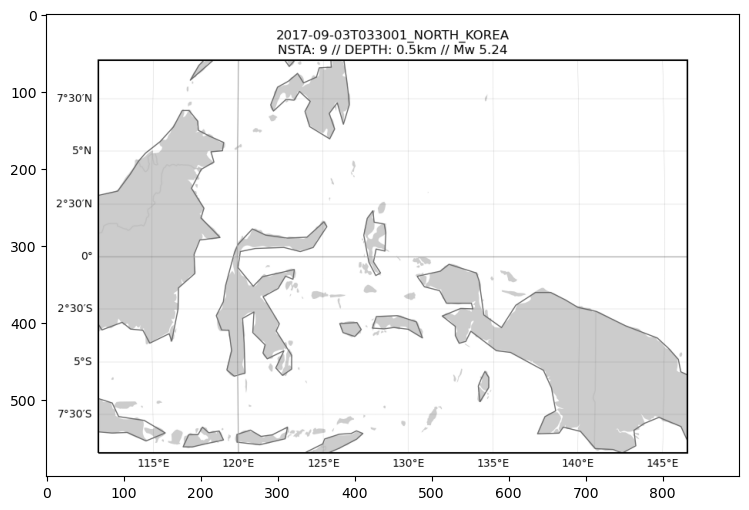

In [4]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2017,9,3,3,30,1"),
                   event_latitude               = 41.3,
                   event_longitude              = 129.078,
                   event_depth_km               = 0.5,
                   event_magnitude              = 5.24 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20170903033001000'                                              

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

## plot data section

In [7]:
# st = read(plotting["pysep_path"]+'/*BHZ*.sac')
# plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
#                             amplitude_scale_factor       = 1,
#                             time_shift_s                 = None,
#                             preprocess                   = 'st',
#                             max_traces_per_rs            = None,
#                             distance_units               = 'km', 
#                             overwrite                    = True,
#                             sort_by                      = 'distance',
#                             **bandpass)

##prepare the configuration file
from obspy.geodetics import gps2dist_azimuth

station_file = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20170903033001000/station_file.txt'
sta_name = np.loadtxt(station_file, usecols=[0], dtype=str)
sta_net = np.loadtxt(station_file, usecols=[1], dtype=str)
sta_lat = np.loadtxt(station_file, usecols=[2], dtype=float)
sta_lon = np.loadtxt(station_file, usecols=[3], dtype=float)


f = open( 'DPRK2017_iris.config', 'w' )
f.write( '#Station    Latitude    Longitude       Distance(km)     Azimuth    Bazimuth\n' )
origin = read_event(evla=41.3, evlo=129.078, evdp=0.5)

for i in range( len(sta_name)):
    sta = sta_net[i] + '.' + sta_name[i]
    stlo = sta_lon[i]
    stla = sta_lat[i]
    dist, az, baz = gps2dist_azimuth(origin.latitude, origin.longitude, stla, stlo)
    
    f.write( '{0:.8s}   {1:,.5f}     {2:,.5f}     {3:,.2f}    {4:,.4f}    {5:,.4f}\n'.format( sta, stla, stlo, dist/1000, az, baz ))

f.close()


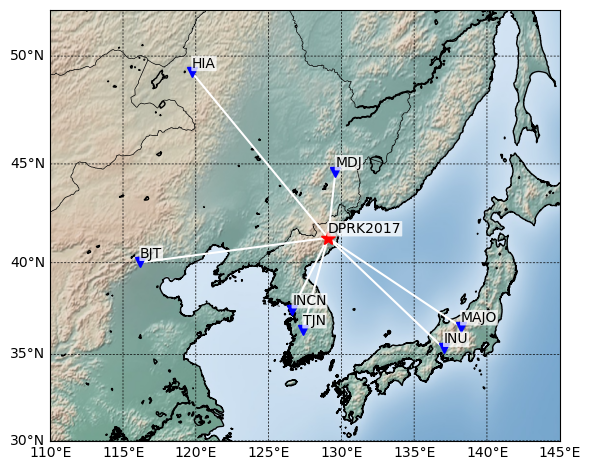

In [9]:
from IO import read_stations, read_event
from mpl_toolkits.basemap import Basemap
## PLOTTING STATION-EVENT CONFIGURATION MAP
evname = '2017'
evdp = 800
stations = read_stations('DPRK2017_iris.config')
origin = read_event(evla=41.3, evlo=129.078, evdp=evdp*1e-3)

## MAP BACKGROUND
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

m = Basemap(projection='merc',llcrnrlat=30,urcrnrlat=52,\
            llcrnrlon=110,urcrnrlon=145,lat_ts=39,resolution='h', ax=ax)
m.shadedrelief()
m.drawcoastlines()
m.drawcountries()
m.drawparallels(np.arange(30, 52.,5.), dashes=[3, 2], linewidth=.5, labels=[1,0,0,0])
m.drawmeridians(np.arange(110, 145.5,5.), dashes=[3, 2], linewidth=.5, labels=[0,0,0,1])
# ## LOCATION OF NUCLEAR TESTS
xx_0, yy_0 = m(origin.longitude, origin.latitude)
## LOCATION OF STATIONS
xx, yy = m([s.longitude for s in stations], [s.latitude for s in stations])

for x, y, s in zip(xx, yy, [s.station for s in stations]):
    plt.plot([xx_0,x],[yy_0,y], color = 'white')
    plt.text(x, y+30e3, s, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.plot(xx, yy, 'v', color='b', markersize=7)    
plt.plot(xx_0, yy_0, '*', color='r', markersize=10)
plt.text(xx_0, yy_0+30e3, 'DPRK'+evname, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.tight_layout()
plt.show()

## Compute Green's functions

In [10]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
from IO import read_stations, read_event

stations = read_stations('DPRK2017_iris.config')
origin = read_event(evla=41.3, evlo=129.078, evdp=0.5)

path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)


    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INU.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/BJT.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/HIA.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MDJ.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INCN.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MAJO.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/TJN.mod


# Download broadband data for DPRK2016a test


preparing to download data ....


[2025-11-05 17:41:22] - pysep - INFO: creating event metadata with user parameters
[2025-11-05 17:41:22] - pysep - INFO: event info summary - origin time: 2016-01-06T01:30:00.000000Z; lat=41.30; lon=129.07; depth[km]=0.5; magnitude=4.48
[2025-11-05 17:41:22] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160106013000000
[2025-11-05 17:41:22] - pysep - INFO: writing config YAML file
[2025-11-05 17:41:22] - pysep - INFO: querying IRIS for station metadata
[2025-11-05 17:42:33] - pysep - INFO: collected 855 channels from 164 stations in 5 networks from IRIS
[2025-11-05 17:42:34] - pysep - INFO: 155 traces outside distance bounds [0, 1300]km
[2025-11-05 17:42:34] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-11-05 17:42:34] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-11-05 17:42:34] - pysep - INFO: querying 9 lines in bulk client request...
[2025-11-05 17:44:28] - pysep - INFO: 39 waveforms returned aft

plotting source station map ....


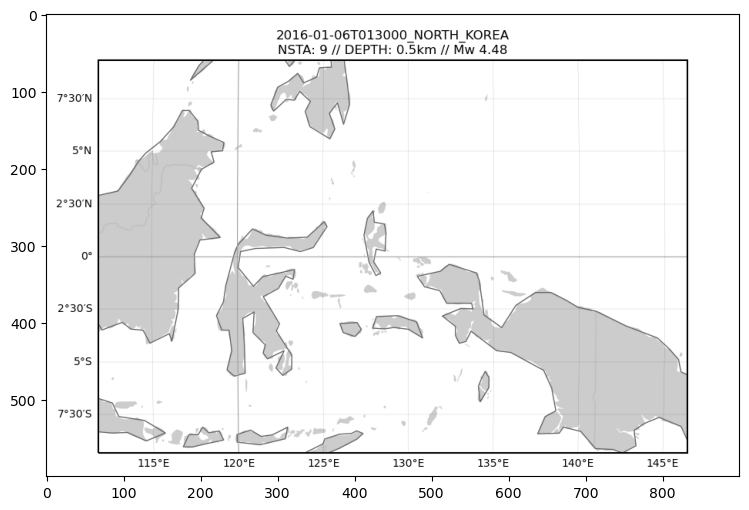

In [4]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2016,1,6,1,30,0"),
                   event_latitude               = 41.3001,
                   event_longitude              = 129.0680,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.48 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20160106013000000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

In [10]:
# st = read(plotting["pysep_path"]+'/*BHZ*.sac')
# plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
#                             amplitude_scale_factor       = 1,
#                             time_shift_s                 = None,
#                             preprocess                   = 'st',
#                             max_traces_per_rs            = None,
#                             distance_units               = 'km', 
#                             overwrite                    = True,
#                             sort_by                    = 'distance',
#                             **bandpass)

##prepare the configuration file
from obspy.geodetics import gps2dist_azimuth
from IO import read_stations, read_event

station_file = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160106013000000/station_file.txt'
sta_name = np.loadtxt(station_file, usecols=[0], dtype=str)
sta_net = np.loadtxt(station_file, usecols=[1], dtype=str)
sta_lat = np.loadtxt(station_file, usecols=[2], dtype=float)
sta_lon = np.loadtxt(station_file, usecols=[3], dtype=float)


f = open( 'DPRK2016a_iris.config', 'w' )
f.write( '#Station    Latitude    Longitude       Distance(km)     Azimuth    Bazimuth\n' )
origin = read_event(evla=41.3001, evlo=129.0680, evdp=0.5)

for i in range( len(sta_name)):
    sta = sta_net[i] + '.' + sta_name[i]
    stlo = sta_lon[i]
    stla = sta_lat[i]
    dist, az, baz = gps2dist_azimuth(origin.latitude, origin.longitude, stla, stlo)
    
    f.write( '{0:.8s}   {1:,.5f}     {2:,.5f}     {3:,.2f}    {4:,.4f}    {5:,.4f}\n'.format( sta, stla, stlo, dist/1000, az, baz ))

f.close()

In [11]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
from IO import read_stations, read_event

stations = read_stations('DPRK2016a_iris.config')
origin = read_event(evla=41.3001, evlo=129.068, evdp=0.5)

path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)

    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INU.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/BJT.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/HIA.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MDJ.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INCN.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MAJO.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/TJN.mod


# Download broadband data for DPRK2016b test


preparing to download data ....


[2025-11-05 19:31:49] - pysep - INFO: creating event metadata with user parameters
[2025-11-05 19:31:49] - pysep - INFO: event info summary - origin time: 2016-09-09T00:30:01.000000Z; lat=41.30; lon=129.08; depth[km]=0.5; magnitude=4.73
[2025-11-05 19:31:49] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160909003001000
[2025-11-05 19:31:49] - pysep - INFO: writing config YAML file
[2025-11-05 19:31:49] - pysep - INFO: querying IRIS for station metadata
[2025-11-05 19:32:59] - pysep - INFO: collected 851 channels from 164 stations in 5 networks from IRIS
[2025-11-05 19:33:00] - pysep - INFO: 155 traces outside distance bounds [0, 1300]km
[2025-11-05 19:33:00] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-11-05 19:33:00] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-11-05 19:33:00] - pysep - INFO: querying 9 lines in bulk client request...
[2025-11-05 19:35:14] - pysep - INFO: 42 waveforms returned aft

plotting source station map ....


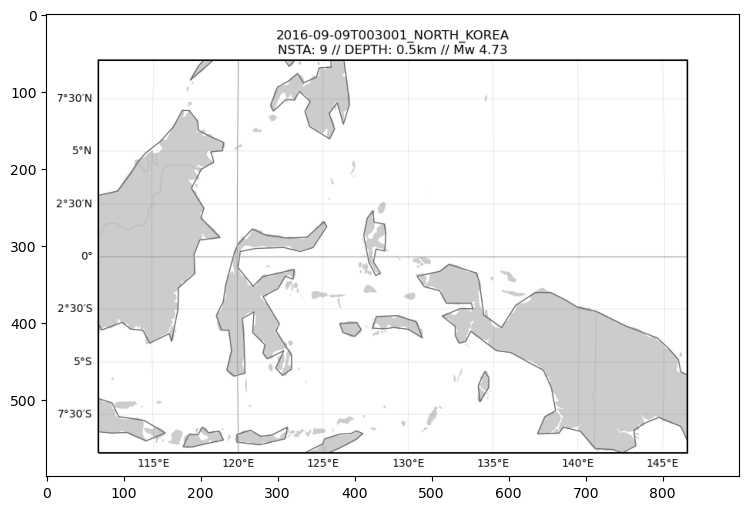

In [12]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2016,9,9,0,30,1"),
                   event_latitude               = 41.2976,
                   event_longitude              = 129.0804,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.73 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20160909003001000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

[2025-11-05 19:36:09] - pysep - INFO: starting record section plotter
[2025-11-05 19:36:09] - pysep - INFO: checking parameter acceptability
[2025-11-05 19:36:09] - pysep - INFO: getting source-receiver stats
[2025-11-05 19:36:09] - pysep - INFO: calculating source-receiver distance and (back)azimuths
[2025-11-05 19:36:09] - pysep - INFO: preprocessing 14 `st` waveforms
[2025-11-05 19:36:09] - pysep - INFO: applying bandpass filter w/ [0.02, 20]
[2025-11-05 19:36:09] - pysep - INFO: calculating starttime offsets from event origin time 2016-09-09T00:30:01.000000Z
[2025-11-05 19:36:09] - pysep - INFO: determining sort order with parameter: distance
[2025-11-05 19:36:09] - pysep - INFO: determining if any stations/channels should be skipped
[2025-11-05 19:36:09] - pysep - INFO: criteria check will remove 0/14 traces
[2025-11-05 19:36:09] - pysep - INFO: determining y-axis positioning for sort: distance
[2025-11-05 19:36:09] - pysep - INFO: determining amplitude scaling w.r.t st with: 'nor

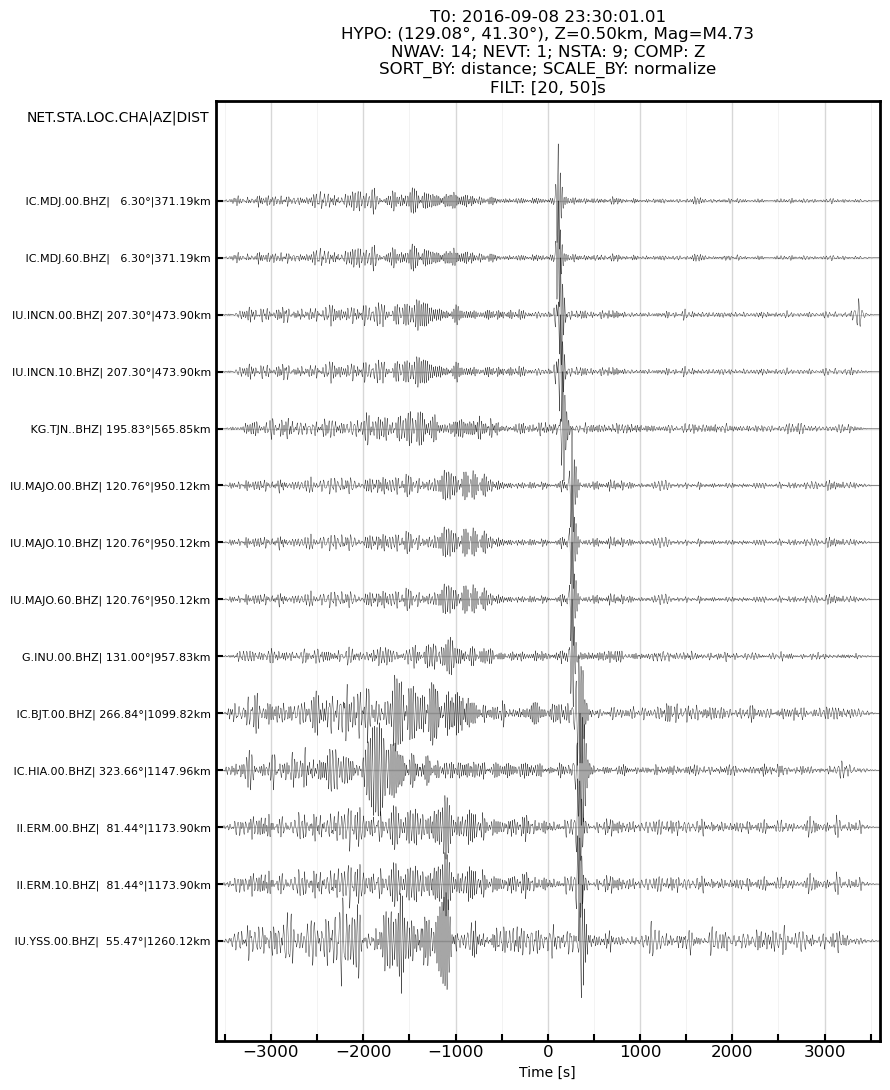

[2025-11-05 19:36:10] - pysep - INFO: finished record section in t=0:00:01.306310s


In [13]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
         
                            **bandpass)
##prepare the configuration file
from obspy.geodetics import gps2dist_azimuth
from IO import read_stations, read_event

station_file = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160909003001000/station_file.txt'
sta_name = np.loadtxt(station_file, usecols=[0], dtype=str)
sta_net = np.loadtxt(station_file, usecols=[1], dtype=str)
sta_lat = np.loadtxt(station_file, usecols=[2], dtype=float)
sta_lon = np.loadtxt(station_file, usecols=[3], dtype=float)


f = open( 'DPRK2016b_iris.config', 'w' )
f.write( '#Station    Latitude    Longitude       Distance(km)     Azimuth    Bazimuth\n' )
origin = read_event(evla=41.2976, evlo=129.0804, evdp=0.5)

for i in range( len(sta_name)):
    sta = sta_net[i] + '.' + sta_name[i]
    stlo = sta_lon[i]
    stla = sta_lat[i]
    dist, az, baz = gps2dist_azimuth(origin.latitude, origin.longitude, stla, stlo)
    
    f.write( '{0:.8s}   {1:,.5f}     {2:,.5f}     {3:,.2f}    {4:,.4f}    {5:,.4f}\n'.format( sta, stla, stlo, dist/1000, az, baz ))

f.close()

In [14]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
from IO import read_stations, read_event

stations = read_stations('DPRK2016b_iris.config')
origin = read_event(evla=41.2976, evlo=129.0804, evdp=0.5)

path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)

    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INU.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/BJT.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/HIA.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MDJ.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/INCN.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/MAJO.mod
/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d/TJN.mod


# Download broadband data for DPRK2009 test

In [ ]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2009,5,25,0,54,43"),
                   event_latitude               = 41.2943,
                   event_longitude              = 129.0778,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.39 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20090525005443000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

In [ ]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

In [ ]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
from IO import read_stations, read_event

stations = read_stations('DPRK2009_iris.config')
origin = read_event(evla=41.2943, evlo=129.0778, evdp=0.5)

path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)

# Download broadband data for DPRK2006 test

In [ ]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2006,10,9,1,35,28"),
                   event_latitude               = 41.2874,
                   event_longitude              = 129.1083,
                   event_depth_km               = 0.5,
                   event_magnitude              = 3.8 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20061009013528000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

In [ ]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

In [ ]:
from obspy.geodetics import gps2dist_azimuth

stations = read_stations('DPRK2006.config')

f = open( 'DPRK2006_iris.config', 'w' )
f.write( '#Station    Latitude    Longitude       Distance(km)     Azimuth    Bazimuth\n' )
origin = read_event(evla=41.2874, evlo=129.1083, evdp=0.5)

for i in range( len(stations )):
    sta_name =stations[i].network +'.'+stations[i].station
    stlo = stations[i].longitude
    stla = stations[i].latitude
    dist, az, baz = gps2dist_azimuth(origin.latitude, origin.longitude, stla, stlo)
    
    f.write( '{0:.8s}   {1:,.5f}     {2:,.5f}     {3:,.2f}    {4:,.4f}    {5:,.4f}\n'.format( sta_name, stla, stlo, dist/1000, az, baz ))

f.close()


In [ ]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor_2D
from IO import read_stations, read_event

stations = read_stations('DPRK2017_iris.config')
origin = read_event(evla=41.3, evlo=129.078, evdp=1.)

path_to_earth_model = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/velmod2d'
generate_CPS_greens_tensor_2D(origin, stations, path_to_earth_model, t0=0, vred=0)

In [ ]:
## INITIAL IMPORTATION
# conda -c conda-forge import emcee corner

%config InlineBackend.figure_format = "retina"
%load_ext autoreload

from matplotlib import rcParams

rcParams["savefig.dpi"] = 300
rcParams["figure.dpi"] = 200
rcParams["font.size"] = 15

from matplotlib import pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
import numpy as np
import os
import glob
from IO import read_stations, read_event
import corner
import emcee
from netCDF4 import Dataset
import emcee
from numpy.fft import rfft, irfft, rfftfreq
import os
import multiprocessing
import matplotlib
from obspy.imaging.mopad_wrapper import beach

from pyrocko.moment_tensor import MomentTensor

def rtp2ned(mt_rtp):
    Mrr, Mtt, Mpp, Mrt, Mrp, Mtp = mt_rtp
    Mzz=Mrr
    Mxx=Mtt
    Myy=Mpp
    Mxz=Mrt
    Myz=-Mrp
    Mxy=-Mtp
    return np.array([Mxx,Myy,Mzz, Mxy,Mxz,Myz])

tmp = np.array([ 1.646389, 2.65590467,   -9.2917976,    1.1153541,  -31.95975384, 26.16631789])
mt = MomentTensor.from_values(tmp )
mt_decom = mt.standard_decomposition()
c_ISO, c_DC, c_CLVD = 100*mt_decom[0][1], 100*mt_decom[1][1], 100*mt_decom[2][1]

print(c_ISO, c_DC, c_CLVD)

In [ ]:
from obspy import read
from obspy.core import UTCDateTime

st = read("/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20170903033001000/*BJT*")
t = UTCDateTime("2017,9,3,3,30,1")
st.resample(1)
st.filter("bandpass", freqmin=0.02, freqmax=0.05)
st.trim(t-3000,t)

for c in 'ZRT':
    print( np.std(st.select(component=c)[0].data, ddof=0))
fig=st.plot()